In [1]:
#Numpy installation for technical reasons
!pip install numpy==1.26.4

In [2]:
#Upgrading pandas and yfinance 
!pip install --upgrade pandas pyarrow yfinance

In [3]:
import yfinance as yf
import pandas as pd

#We give the tickers of the 3 stocks (Procter & Gamble, Pepsi, Colgate-Palmolive)
tickers = ['PG', 'PEP', 'CL']  

all_data = pd.DataFrame()

#Download the data from 5 years ago 
#Display the closing prices in a matrix 
for t in tickers:
    print(f"\nDownloading data for: {t}")
    try:
        ticker = yf.Ticker(t)
        df = ticker.history(start="2020-01-01", end="2025-01-01", interval="1d")['Close'] #Close is the same as Adj Close
        df.name = t  # Set the series name to the ticker symbol
        all_data = pd.concat([all_data, df], axis=1)
        print(f"Finished for: {t}")
    except Exception as e:
        print(f"Error for {t}: {e}")

print("\nTotal data:")
print(all_data.tail())


c:\Users\ionak\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\ionak\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (



Finished for: PG

Finished for: PEP

Finished for: CL

Total data:
                                   PG         PEP         CL
2024-12-24 00:00:00-05:00  162.209656  145.637009  89.106003
2024-12-26 00:00:00-05:00  163.381058  145.284363  89.086716
2024-12-27 00:00:00-05:00  162.776154  145.713242  88.546616
2024-12-30 00:00:00-05:00  160.433365  144.598190  87.562874
2024-12-31 00:00:00-05:00  160.971054  144.922195  87.678612


In [4]:
# Calculate the returns 
returns = all_data.pct_change().dropna()

# Display the last 5 years returns
returns.tail()


,PG,PEP,CL
2024-12-24 00:00:00-05:00,0.004937,0.010047,0.005222
2024-12-26 00:00:00-05:00,0.007222,-0.002421,-0.000216
2024-12-27 00:00:00-05:00,-0.003702,0.002952,-0.006063
2024-12-30 00:00:00-05:00,-0.014393,-0.007652,-0.011110
2024-12-31 00:00:00-05:00,0.003351,0.002241,0.001322


In [5]:
# Define the weights for each stock 
weights = [0.4, 0.3, 0.3]

# Calculate the daily returns of our portfolio
portfolio_returns = returns.dot(weights)

# Display the returns
portfolio_returns.tail()



2024-12-24 00:00:00-05:00    0.006556
2024-12-26 00:00:00-05:00    0.002097
2024-12-27 00:00:00-05:00   -0.002414
2024-12-30 00:00:00-05:00   -0.011386
2024-12-31 00:00:00-05:00    0.002409
dtype: float64

In [6]:
# VaR with historical method for confidence level 95% and 99%
var_95_hs = portfolio_returns.quantile(0.05)
var_99_hs = portfolio_returns.quantile(0.01)

print(f"VaR 95% (historical): {var_95_hs:.4f}")
print(f"VaR 99% (historical): {var_99_hs:.4f}")


VaR 95% (historical): -0.0168
VaR 99% (historical): -0.0300


In [7]:
import numpy as np

mean = portfolio_returns.mean()
std_dev = portfolio_returns.std()

# Z-values for 95% and 99%
z_95 = 1.65
z_99 = 2.33

var_95_vc = mean - z_95 * std_dev
var_99_vc = mean - z_99 * std_dev

print(f"VaR 95% (variance-covariance): {var_95_vc:.4f}")
print(f"VaR 99% (variance-covariance): {var_99_vc:.4f}")


VaR 95% (variance-covariance): -0.0197
VaR 99% (variance-covariance): -0.0279


In [8]:
# Rolling VaR – Historical Simulation
rolling_window_size = 126  # 6 months 

rolling_var_95_hs = portfolio_returns.rolling(window=rolling_window_size).quantile(0.05)
rolling_var_99_hs = portfolio_returns.rolling(window=rolling_window_size).quantile(0.01)


In [9]:
portfolio_returns


2020-01-03 00:00:00-05:00   -0.003550
2020-01-06 00:00:00-05:00    0.003778
2020-01-07 00:00:00-05:00   -0.011309
2020-01-08 00:00:00-05:00    0.010889
2020-01-09 00:00:00-05:00    0.007131
                               ...   
2024-12-24 00:00:00-05:00    0.006556
2024-12-26 00:00:00-05:00    0.002097
2024-12-27 00:00:00-05:00   -0.002414
2024-12-30 00:00:00-05:00   -0.011386
2024-12-31 00:00:00-05:00    0.002409
Length: 1257, dtype: float64

In [10]:
import numpy as np

# Rolling mean returns and its standard deviation 
rolling_mean = portfolio_returns.rolling(window=rolling_window_size).mean()
rolling_std = portfolio_returns.rolling(window=rolling_window_size).std()

# VaR calculation with normal distribution
z_95 = 1.65
z_99 = 2.33

rolling_var_95_vc = rolling_mean - z_95 * rolling_std
rolling_var_99_vc = rolling_mean - z_99 * rolling_std


In [11]:
lambda_ = 0.94  # Recommended price from JP Morgan
ewma_var = []   # Empty list so we can calculate std
# We start from the first rolling_std price
prev_var = portfolio_returns[:126].var()  # First price

for r in portfolio_returns[126:]:
    prev_var = lambda_ * prev_var + (1 - lambda_) * r**2
    ewma_var.append(prev_var)

# Turn into Pandas Series
import numpy as np
ewma_std = pd.Series(np.sqrt(ewma_var), index=portfolio_returns[126:].index)


In [12]:
z_95 = 1.65
z_99 = 2.33

ewma_var_95 = -z_95 * ewma_std
ewma_var_99 = -z_99 * ewma_std


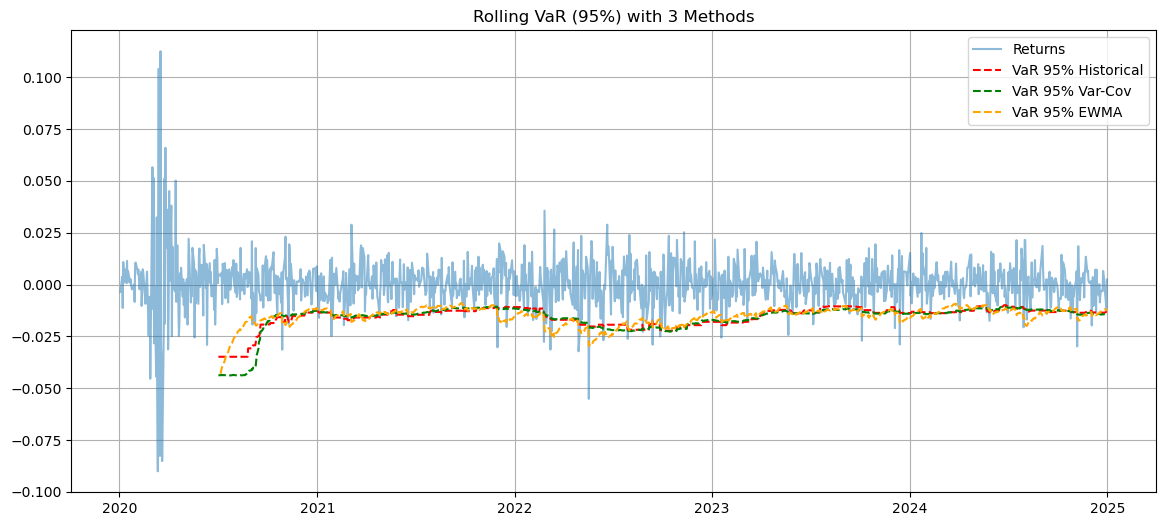

In [13]:
# Import matplotlib.pyplot library
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(portfolio_returns, label='Returns', alpha=0.5)

# Previous VaR(historical simulation-variance-covariance)
plt.plot(rolling_var_95_hs, label='VaR 95% Historical', linestyle='--', color='red')
plt.plot(rolling_var_95_vc, label='VaR 95% Var-Cov', linestyle='--', color='green')

#VaR with EWMA method (Exponentially Weighted Moving Average)
plt.plot(ewma_var_95, label='VaR 95% EWMA', linestyle='--', color='orange')

plt.title('Rolling VaR (95%) with 3 Methods')
plt.legend()
plt.grid(True)

In [14]:
# We align returns with the index of each VaR series
returns_hist = portfolio_returns.reindex(rolling_var_95_hs.index)
returns_vc   = portfolio_returns.reindex(rolling_var_95_vc.index)
returns_ewma = portfolio_returns.reindex(ewma_var_95.index)

# Calculate exceptions
exceptions_hist = returns_hist < rolling_var_95_hs
exceptions_vc   = returns_vc   < rolling_var_95_vc
exceptions_ewma = returns_ewma < ewma_var_95

# Results
print("Exceptions (95% confidence level):\n")
print(f"Historical: {exceptions_hist.sum()} σε {len(exceptions_hist)} days")
print(f"Var-Cov: {exceptions_vc.sum()} in {len(exceptions_vc)} days")
print(f"EWMA: {exceptions_ewma.sum()} in {len(exceptions_ewma)} days")


Exceptions (95% confidence level):

Historical: 57 σε 1257 days
Var-Cov: 54 in 1257 days
EWMA: 52 in 1131 days


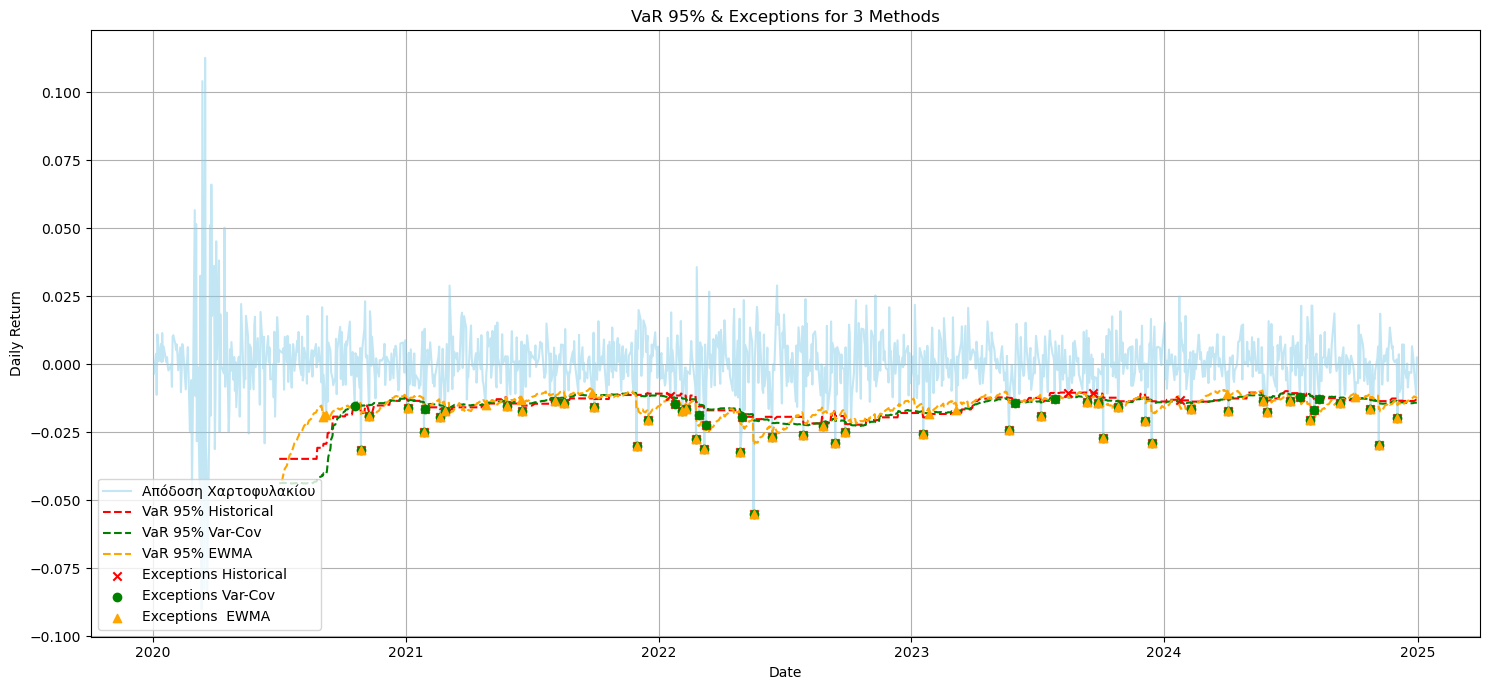

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))

# Portfolio returns
plt.plot(portfolio_returns, label='Απόδοση Χαρτοφυλακίου', color='skyblue', alpha=0.5)

# VaR 95% for each method
plt.plot(rolling_var_95_hs, label='VaR 95% Historical', linestyle='--', color='red')
plt.plot(rolling_var_95_vc, label='VaR 95% Var-Cov', linestyle='--', color='green')
plt.plot(ewma_var_95, label='VaR 95% EWMA', linestyle='--', color='orange')

# Exceptions Historical
plt.scatter(returns_hist[exceptions_hist].index,
            returns_hist[exceptions_hist],
            color='red', marker='x', label='Exceptions Historical', zorder=5)

# Exceptions Var-Cov
plt.scatter(returns_vc[exceptions_vc].index,
            returns_vc[exceptions_vc],
            color='green', marker='o', label='Exceptions Var-Cov', zorder=5)

# Exceptions EWMA
plt.scatter(returns_ewma[exceptions_ewma].index,
            returns_ewma[exceptions_ewma],
            color='orange', marker='^', label='Exceptions  EWMA', zorder=5)

plt.title('VaR 95% & Exceptions for 3 Methods')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
from scipy.stats import chi2
import numpy as np

#Implement the Kupiec Test
def kupiec_test(x, n, p=0.05):
    LR_uc = -2 * (np.log(((1 - p)**(n - x) * p**x)) -
                  np.log(((1 - x/n)**(n - x) * (x/n)**x)))
    p_value = 1 - chi2.cdf(LR_uc, df=1)
    return LR_uc, p_value

print("KUPIEC TEST – 95% VaR\n")

# Historical
x_hist = exceptions_hist.sum()
n_hist = len(exceptions_hist)
LR_hist, p_hist = kupiec_test(x_hist, n_hist)

# Var-Cov
x_vc = exceptions_vc.sum()
n_vc = len(exceptions_vc)
LR_vc, p_vc = kupiec_test(x_vc, n_vc)

# EWMA
x_ewma = exceptions_ewma.sum()
n_ewma = len(exceptions_ewma)
LR_ewma, p_ewma = kupiec_test(x_ewma, n_ewma)

# Εμφάνιση
print(f"Historical:\tLR = {LR_hist:.4f}, p-value = {p_hist:.4f} ➤ {'Accept' if p_hist > 0.05 else 'Reject'}")
print(f"Var-Cov:\tLR = {LR_vc:.4f}, p-value = {p_vc:.4f} ➤ {'Accept' if p_vc > 0.05 else 'Reject'}")
print(f"EWMA:\t\tLR = {LR_ewma:.4f}, p-value = {p_ewma:.4f} ➤ {'Accept' if p_ewma > 0.05 else 'Reject'}")


KUPIEC TEST – 95% VaR

Historical:	LR = 0.5908, p-value = 0.4421 ➤ Accept
Var-Cov:	LR = 1.3746, p-value = 0.2410 ➤ Accept
EWMA:		LR = 0.3956, p-value = 0.5294 ➤ Accept
